# The Bayesian Approach with Plug and Play (PnP) prior

**Authors:**
* Yiming Xi

* Teresa Klatzer

This numerical tour follows a Bayesian approach with Plug and Play (PnP) priors for solving inverse problems. These data-driven approach make use of learned implicit representation of the prior density while keeping an explicit likelihood density. Our aim is to perform image deconvolution and uncertainty quantification using [Langevin algorithms](https://epubs.siam.org/doi/abs/10.1137/21M1406349?journalCode=sjisbi) for sampling under PnP priors.

## Introduce a Plug and Play prior

We outline the way PnP priors can be used for Bayesian computation. For more details look the work of [Remi and al.](https://epubs.siam.org/doi/abs/10.1137/21M1406349?journalCode=sjisbi). Suppose the existence of an optimal and intractable prior distribution over $x$, namely $p^*(x)$, and an optimal posterior distribution over $x|y$, namely $p^*(x|y)$. The posterior distribution associated with the optimal $p^*(x)$ is given as

$$p^*(x|y) = \dfrac{p(y|x)p^*(x)}{\int_{\mathbb{R}^d}p(y|\tilde{x})p^*(\tilde{x})d\tilde{x}} ~~~,$$

Since $p^*$ and its respective Lebesque measure are unknown, it is not straightforward to verify that $p^*(x|y)$ is proper and differentiable or that $\nabla \log p^*(x|y)$ is Lipschitz continuous - an important feature for convergent gradient-based algorithms. Thus, we approximate $p^*$ by a smooth density $p_\epsilon^*=G_\epsilon p^*$ where $G_\epsilon$ is a Gaussian smoothing kernel of bandwidth $\epsilon>0$. \\
Then, by definition

$$p_\epsilon^*(x) = (2\pi\epsilon)^{-d/2} \int_{\mathbb{R}^d} \exp\left[-\frac{||x-\tilde{x}||_2^2}{2\epsilon}\right]p^*(\tilde{x})d\tilde{x} ~~~,$$

$$p_\epsilon^*(x|y) = \dfrac{p(y|x)p_\epsilon^*(x)}{\int_{\mathbb{R}^d}p(y|\tilde{x})p_\epsilon^*(\tilde{x})d\tilde{x}} ~~~.$$


The core idea of Bayesian computation with PnP priors is to perform approximate inference w.r.t. $p_\epsilon^*(x|y)$ and consequently make use of the $\nabla \log p_\epsilon^*(x|y)$. Specifically, we introduce the oracle MMSE denoiser $D^{*}_{\epsilon}$ defined as

$$D^{*}_{\epsilon}(x) = (2\pi\epsilon)^{-d/2} \int_\mathbb{R}  \tilde{x}\exp\left[-\frac{||x-\tilde{x}||_2^2}{2\epsilon}\right]p^*(\tilde{x})d\tilde{x} ~~~.$$

It can be seen that $D^{*}_{\epsilon}$ is the MMSE estimator to recover an image $x \sim p^*(x)$ from a noisy observation $x_\epsilon\sim \mathcal{N}(x, \epsilon I)$. To associate $D^{*}_{\epsilon}$ with the gradient $x \rightarrow \nabla \log p_\epsilon^*(x)$, we make use of the Tweedie's identity which states that

$$\nabla \log p_\epsilon^*(x) = \frac{1}{\epsilon}(D^{*}_{\epsilon}(x) - x) ~~~.$$

Then, we can  express  a  ULA  recursion  for  sampling approximately from $p^*_\epsilon(x|y)$ as

$$X_{k+1} = X_{k} + \delta\nabla \log p^*_\epsilon(X_{k}|y ) + \sqrt{2\delta}Z_{k+1}  = X_{k} + \delta\nabla \log p(y|X_{k}) + \frac{\delta}{\epsilon}(D_\epsilon^*(X_{k})-X_{k}) + \sqrt{2\delta}Z_{k+1} ~~.$$

Since $D_\epsilon^*(\cdot)$ is intractable, we use the above equation as a starting point and we replace $D_\epsilon^*(\cdot)$ by a surrogate denoiser $D_\epsilon(\cdot)$ to approximate $ p_\epsilon^*(x|y)$ by the posterior density $p_\epsilon(x|y)$ related to $D_\epsilon(\cdot)$.

## Setting up a deconvolution problem
In this example, we have a deconvolution problem where the operator $A$ corresponds to a blurring operator. Deconvolution corresponds to removing the blur from the image.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!unzip /content/drive/MyDrive/lab2_PnP.zip #change it to the zip file path

unzip:  cannot find or open /content/drive/MyDrive/lab2_PnP.zip, /content/drive/MyDrive/lab2_PnP.zip.zip or /content/drive/MyDrive/lab2_PnP.zip.ZIP.


In [ ]:
import math
import torch
import numpy as np
import time as time
from tqdm.auto import tqdm
from PIL import Image

import sys
import os
parent_dir_of_sampling_tools = 'lab2_PnP/sampling-tutorials-main' #change it to your file path
if parent_dir_of_sampling_tools not in sys.path:
    sys.path.append(parent_dir_of_sampling_tools)

from sampling_tools import *

# Check if there's a GPU available and run on GPU, otherwise run on CPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [ ]:
device

device(type='cuda')

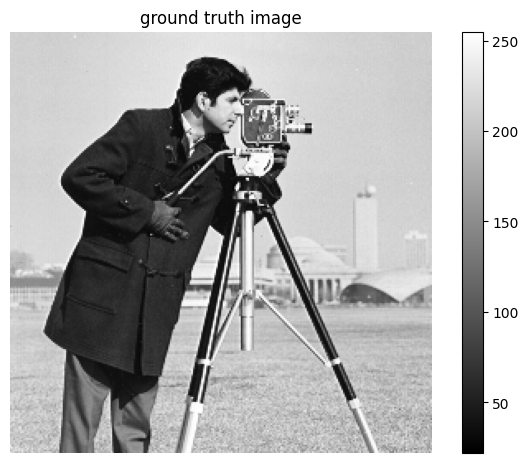

In [ ]:
# Load grayscale image
im = np.array(Image.open("lab2_PnP/sampling-tutorials-main/cman.png")) #change it to your file path
plot_im(im, "ground truth image")

# Convert to torch tensor
x = torch.Tensor(im/255.).to(device)

We define the convolution kernel $A$ in Fourier space. Here a $5\times 5$ uniform blur is used. The `blur_operators()` function returns the functions handles $A$ and $A^T$ that implement the forward operations $Ax$ and $A^Tx$ respectively (computed by calling $A(x)$ and $AT(x)$) as well as the spectral norm $||AA^T||_{2}^{2}$.

The calculation of $||AA^T||_{2}^{2}$ is necessary since it appears in the Lipschitz constant of the model and plays a role for the stepsize of the presented algorithms.

In [ ]:
kernel_len = [5,5]
size = [im.shape[0],im.shape[1]]
type_blur = "uniform"
A, AT, AAT_norm = blur_operators(kernel_len, size, type_blur, device)

We apply the blur operator and add some noise to obtain the measurements $y = Ax + w$ and achieve a blurred signal-to-noise ratio (BSNR) of $40$ dB.

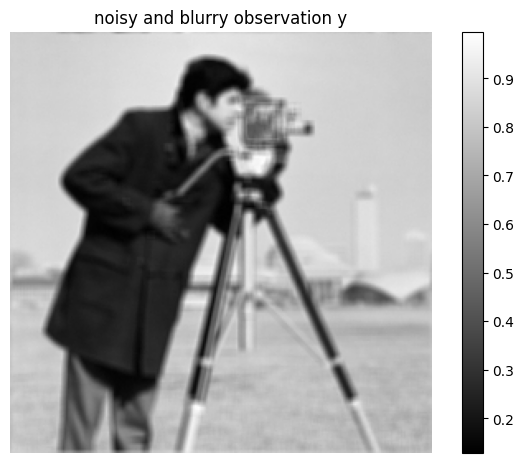

In [ ]:
y0 = A(x)

BSNRdb = 40
sigma = torch.linalg.matrix_norm(A(x)-torch.mean(A(x)), ord='fro')/math.sqrt(torch.numel(x)*10**(BSNRdb/10))

y = y0 + sigma * torch.randn_like(x)
plot_im(y, "noisy and blurry observation y")

## Likelihood

Since, we assumed Gaussian noise, the likelihood $p(y|x)$ is Gaussian given from the forward model $y = Ax + w$. Here we keep track of the negative log-likelihood $$-\log p(y|x) = f_y(x) =\dfrac{1}{2\sigma^2}||y-Ax||^{2}_{2}.$$

In [ ]:
f=lambda x,A: (torch.linalg.matrix_norm(y-A(x),ord='fro')**2.0)/(2.0*sigma**2)

Define the gradient of the negative log-likelihood $f_{y}$.
$$\nabla f_y(x) = A^T(Ax - y).$$

In [ ]:
gradf=lambda x,A,AT: AT(A(x)-y)/sigma**2

The Lipschitz constant $L_{y}$ related to the specific likelihood's gradient (useful for the stepsize choice) is $\dfrac{||AA^T||_2}{\sigma^2}$. We calculated $||AA^T||_2$ earlier.

In [ ]:
L_y=AAT_norm/sigma**2

### Load the denoiser

Below, we load the denoiser $D_\epsilon(\cdot)$ which is a pretrained residual network presented in [Ryu and al.](https://proceedings.mlr.press/v97/ryu19a) with controlled Lipschitz constant $L = 1$. The Lipschitz continuity of the denoiser is important since this guarantees that $\nabla \log p_\epsilon(x|y)$ is also Lipschitz. Since the network is residual, $D_\epsilon(\cdot) = x - D'_\epsilon(\cdot)$, where $D'_\epsilon(\cdot)$ is the loaded network, denoted as `denoise()` and `model()` respectively. Finally, we assume that the denoiser $D'_\epsilon(\cdot)$ is pretrained at noise level of $\epsilon=5/255$.

In [ ]:
L_net = 1.0
# keep in mind that we've got a residual network
model = load_model('lab2_PnP/sampling-tutorials-main/Pretrained_models/RealSN_DnCNN_noise15.pth', 'cuda')
denoise = lambda x: (x - model(x[None][None])[0][0]).detach()

## PnP Algorithms
For convergence verification reasons, instead of targeting the posterior $p_{\epsilon}(X_{t}|y)$, we will target $p_{\epsilon,C}(X_{t}|y)$ where

$$p_{\epsilon,C}(X_{t}|y)=p_{\epsilon}(X_{t}|y)e^{-d^{2}(x,C)/\lambda}\,\,,$$

where $C\subset \mathbb{R}^{d}$ is some large compact convex set that controls the far tail behaviour of $p_{\epsilon,C}$ and $d(x, C)$ is the minimum Euclidean distance between $x$ and the set $C$, and $\lambda>0$ is a tail regularisation parameter. It is easy to check that

$$\nabla \log p_{\epsilon,C}(X_{t}|y) = \nabla \log p_{\epsilon}(X_{t}|y) + \dfrac{1}{\lambda}(\Pi_{C}(X_{t})-X_{t})\,\,,$$

where $\Pi_{C}(\cdot)$ denotes the projection function to the convex set $C$. We define **PnP-ULA** as the following recursion:  

$$X_{k+1} = X_{k} + \delta\nabla \log p_{\epsilon, C}(X_{k}|y) + \sqrt{2\delta}Z_{k+1}  = X_{k} + \delta\nabla \log p(y|X_{k}) + \frac{\alpha\delta}{\epsilon}(D_\epsilon(X_{k})-X_{k}) + \dfrac{\delta}{\lambda}(\Pi_{C}(X_{t})-X_{t}) + \sqrt{2\delta}Z_{k+1} ~~.$$

Alternative strategy is to modify PnP-ULA to include a hard projection onto $C$, and define the **projected  PnP-ULA (PPnP-ULA)** as the following recursion:

$$X_{k+1} = \Pi_{C}(X_{k} + \delta\nabla \log p_{\epsilon}(X_{k}|y) + \sqrt{2\delta}Z_{k+1})  = \Pi_{C}\left(X_{k} + \delta\nabla \log p(y|X_{k}) + \frac{\alpha\delta}{\epsilon}(D_\epsilon(X_{k})-X_{k}) + \sqrt{2\delta}Z_{k+1}\right) ~~.$$

It should be noted that the hard projection guarantees geometric convergence with weaker restrictions on $\delta$ and hence PPnP-ULA can converge faster than PnP-ULA, with the expense of more bias. Finally, note the presence of a regularisation parameter $\alpha$ in these algorithms, which permits to balance the weights between the prior and data terms.

### Setting parameters

For this notebook, we set the noise level $\epsilon$ of the denoiser to be $5/255$. We also set $\lambda = (2L/\epsilon + 4L_y)^{-1}$. These are guidelines suggested [here](https://epubs.siam.org/doi/abs/10.1137/21M1406349?journalCode=sjisbi).

In [ ]:
alpha = 1
eps =  (5/255)**2
max_lambd = 1.0/((2.0*alpha*L_net)/eps+4.0*L_y)
lambd_frac = 0.99
lambd = max_lambd*lambd_frac

C_upper_lim = torch.tensor(1).to(device)
C_lower_lim = torch.tensor(0).to(device)

### PnP-ULA and PPnP-ULA kernel updates

Below, we define the kernel updates based on the algorithm presented above.

In [ ]:
projbox = lambda x: torch.clamp(x, min = C_lower_lim, max = C_upper_lim)

def Markov_kernel(X, delta, projected):
    if projected:
        X=projbox(X+delta*gradf(X,A,AT)+alpha*delta*denoise(X)/eps+torch.sqrt(2*delta)*torch.randn_like(X))
    else:
        X+=delta*gradf(X,A,AT)+alpha*delta*denoise(X)/eps+delta*(projbox(X)-X)/lambd+torch.sqrt(2*delta)*torch.randn_like(X)
    return X

### Setting the stepsize

It should be noted that $\delta$ is subject to a numerical stability constraint related to the inverse of the Lipschitz constant of $\nabla \log p_\epsilon(x|y)$. For **PnP-ULA** we require $\delta < (1/3) L_{total}^{-1}$, where $ L_{total} = (\alpha L)/\epsilon+L_y+1/\lambda$. For **PPnP-ULA**, we require $\delta < (L/\epsilon+L_y)^{-1}$.

In [ ]:
projected = True

if projected:
    delta_max = (1.0)/(L_net/eps+L_y)
else:
    delta_max = (1.0/3.0)/((alpha*L_net)/eps+L_y+1/lambd)
delta_frac = 0.99
delta = delta_max*delta_frac

### Bayesian computations

We calculate the posterior mean as
$$\hat{x}_{MMSE} = \mathbb{E}(x|y) = \int_{\mathbb{R}^{d}}\tilde{x}p_\epsilon(\tilde{x}|y)d\tilde{x}\approx \dfrac{1}{N}\sum_{i=1}^{N}X_{i}$$

and the posterior variance for each image pixel $x_{i}$, for $i = 1,\ldots,d$, as

$$\operatorname{Var}(x_i|y) = \mathbb{E}(x_i^{2}|y) - (\mathbb{E}(x_i|y))^{2} \approx \dfrac{1}{N}\sum_{i=1}^{N}X_{i}^2 - \left(\dfrac{1}{N}\sum_{i=1}^{N}X_{i}\right)^2\,\,.$$

Additionally, we are keeping track of the reconstruction quality of the MMSE estimate by calculating the Normalized Mean Square Error (NRMSE), the Peak-Signal-to-Noise Ratio (PSNR) and the Structural Similarity Index Measure (SSIM) w.r.t. the ground truth image.

### Algorithm choices and initializations

Choose the number of sampling iterations, here it is $10^{4}$. A burn-in period of $5\%$ is also included.  The Markov chain is initialized with the observation $y$. In total, we would like to save a trace of 2000 samples, so we set the thinning variable accordingly. In practice, you will need to run the sampling for longer (500k-1m iterations) for uncertainty quantification (UQ) tasks, but this is enough to illustrate how it works.

In [ ]:
maxit = 10000
burnin = np.int64(maxit*0.05)
n_samples = np.int64(2000)
X = y.clone()
MC_X = []
thinned_trace_counter = 0
thinning_step = np.int64(maxit/n_samples)

### Quality metrics
Keep track of the NRMSE, PSNR, SSIM w.r.t. to the ground truth image and the log-posterior on the fly.

In [ ]:
nrmse_values = []
psnr_values = []
ssim_values = []

### The Algorithm in Practice

1. Each iteration is calculated using the PnP-ULA kernel.

2. After the burning-period we start calculating the posterior sample mean and variance on the fly by updating them in each iteration. We are using the `welford` class for this. The `update()` function of the class updates the sample mean and variance in each iteration.

3. We also keeping track of the samples in the Fourier domain calculating respective the posterior mean and variance on the fly in the Fourier domain. This can be accomplished by just giving as input in the `welford` class the absolute value of the FT of the samples.


In [ ]:
start_time = time.time()
for i_x in tqdm(range(maxit)):

    # Update X
    X = Markov_kernel(X, delta, projected=projected)

    if i_x == burnin:
        # Initialise recording of sample summary statistics after burnin period
        post_meanvar = welford(X)
        absfouriercoeff = welford(torch.fft.fft2(X).abs())
        count=0
    elif i_x > burnin:
        # update the sample summary statistics
        post_meanvar.update(X)
        absfouriercoeff.update(torch.fft.fft2(X).abs())

        # collect quality measurements
        current_mean = post_meanvar.get_mean()
        nrmse_values.append(NRMSE(x, current_mean))
        psnr_values.append(PSNR(x, current_mean))
        ssim_values.append(SSIM(x, current_mean))

        # collect thinned trace
        if count == thinning_step-1:
            MC_X.append(X.detach().cpu().numpy())
            count = 0
        else:
            count += 1

end_time = time.time()
elapsed = end_time - start_time

  0%|          | 0/10000 [00:00<?, ?it/s]

Evaluate metrics of noisy image $y$.

In [ ]:
print(f"Initial NRMSE: {NRMSE(x,y):.4f}")
print(f"Initial PSNR: {PSNR(x,y):.2f} dB")
print(f"Initial SSIM: {SSIM(x,y):.4f}")

Initial NRMSE: 0.1174
Initial PSNR: 21.61 dB
Initial SSIM: 0.6958


Evaluate metrics of posterior mean.


In [ ]:
print(f"Result NRMSE: {NRMSE(post_meanvar.get_mean(),x):.4f}" )
print(f"Result PSNR: {PSNR(post_meanvar.get_mean(),x):.2f} dB")
print(f"Result SSIM: {SSIM(post_meanvar.get_mean(),x):.4f}")

Result NRMSE: 1.4874
Result PSNR: 2.01 dB
Result SSIM: -0.0134


## Plotting Results
We display below the ground truth and noisy and blurry image, the posterior mean (**MMSE** solution of the inverse problem), the posterior variance (which is useful for quantifying the uncertainties) and further statistics in the second row. More specifically, we display ratios of the posterior mean over the posterior standard deviation (SD, taking the root of the variance) as well as the ratio of the SD over the posterior mean in the spatial domain (so called coefficients of variation), and the mean and variance in log scale in Fourier domain. The following row shows the image quality metrics (NMRSE, PSNR, SSIM) for the cumulative mean, which tells us about the convergence of the algorithm (when the curves are completely flattened out).

/content/lab2_PnP/sampling-tutorials-main/sampling_tools/plots.py:90: RuntimeWarning: invalid value encountered in divide
  axes[1,0].imshow(post_mean_numpy/np.sqrt(post_meanvar.get_var().detach().cpu().numpy()), cmap="gray")
/content/lab2_PnP/sampling-tutorials-main/sampling_tools/plots.py:97: RuntimeWarning: invalid value encountered in divide
  axes[1,1].imshow(np.sqrt(post_var_numpy)/post_mean_numpy,cmap="gray")


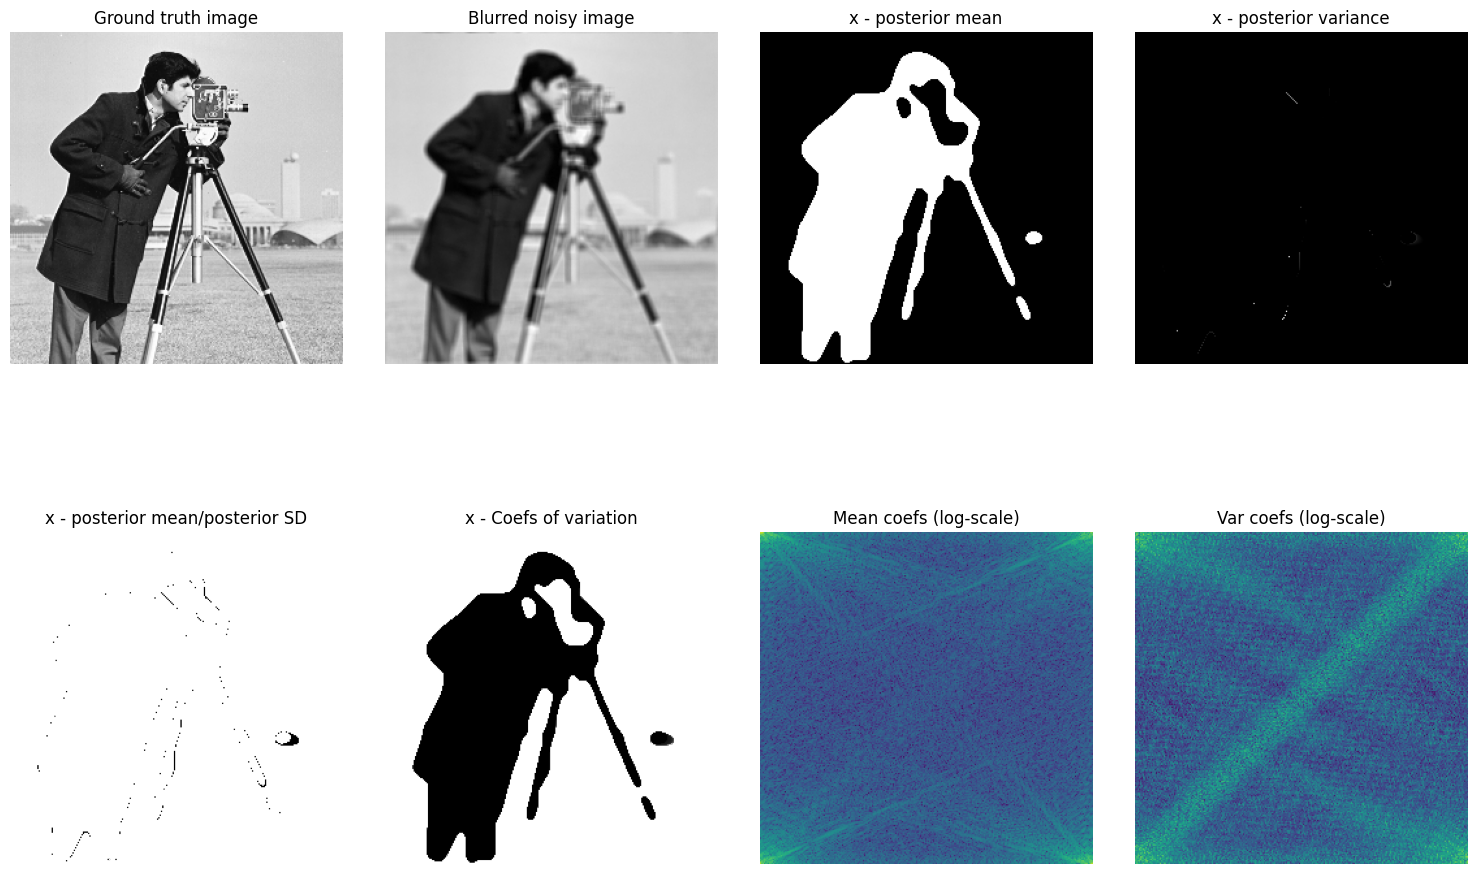

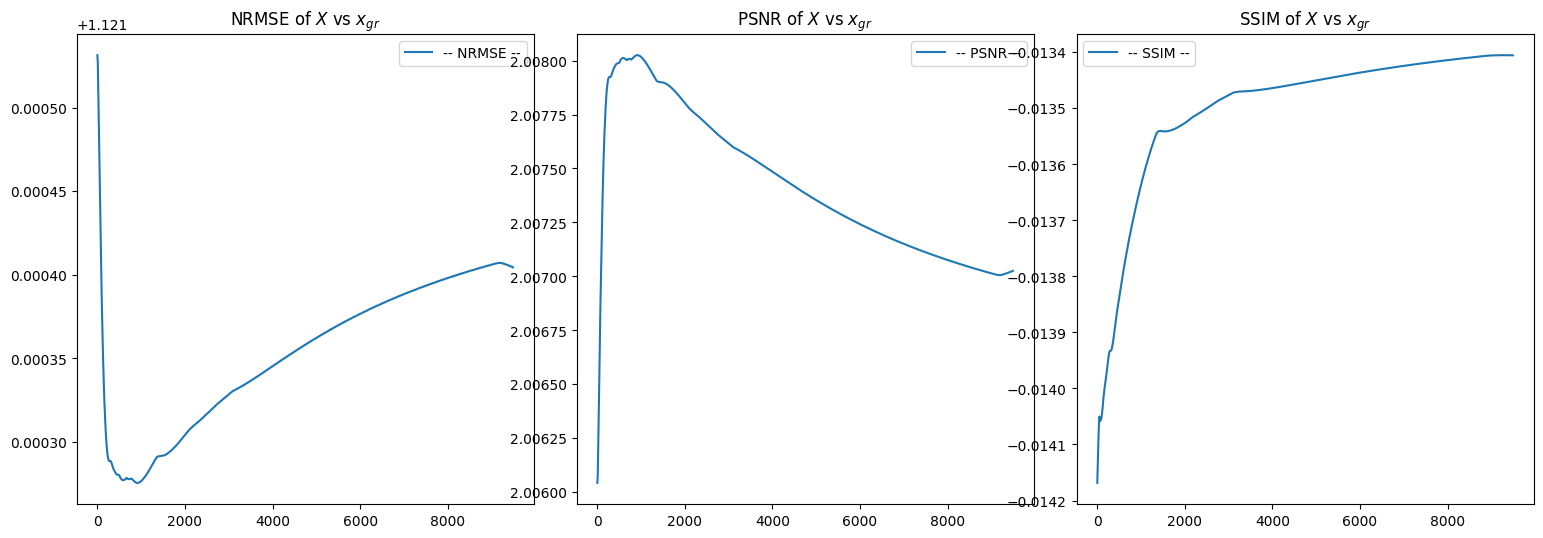

In [ ]:
plots(x, y, post_meanvar, absfouriercoeff, nrmse_values, psnr_values, ssim_values)